# 국립중앙박물관 유료입장 전환 시 최적 입장료 분석
## Step 2: 리뷰 감성분석 + 토픽모델링

**목적**: 세계 주요 박물관 리뷰를 분석하여 방문객이 가치를 느끼는 요소와 가격 민감도를 파악한다.

**분석 흐름**:
1. 데이터 로드 & 전처리
2. 감성분석 (사전 기반)
3. 토픽모델링 (LDA)
4. 유료 vs 무료 박물관 비교
5. 인사이트 도출

**필요 라이브러리**: pandas, numpy, sklearn, matplotlib, seaborn


## 0. 환경 설정

In [32]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import warnings
warnings.filterwarnings('ignore')
from langdetect import detect

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

DATA_DIR = '../data/'
OUTPUT_DIR = '../output/'

## 1. 데이터 로드 & 전처리

In [36]:
# 리뷰 데이터 로드
df = pd.read_csv(f'{DATA_DIR}museum_review.csv')
print(f'전체 리뷰: {len(df)}')
print(f'컬럼: {df.columns.tolist()}')
print(f'박물관 수: {df["museum_id"].nunique()}')
print(f'텍스트 없는 리뷰: {df["text"].isna().sum()}')

# 텍스트 없는 리뷰 제거
df = df[df['text'].notna()].copy()
df['text'] = df['text'].astype(str)
print(f'\n분석 대상 리뷰: {len(df)}')

# State Russian Museum 제거, 영어리뷰 아닌것 제거(대부분 러시아어라 의미 없음)
df = df[df['museum_id'] != 1011]
df['lang'] = df['text'].apply(detect)
df = df[df['lang'] == 'en']

# 별점 분포
print(f'\n별점 분포:')
print(df['stars'].value_counts().sort_index())

# 박물관별 리뷰 수
print(f'\n박물관별 리뷰 수:')
print(df.groupby('museum_id').size().sort_values(ascending=False))
print(df.describe())

print(f'전체 리뷰: {len(df)}')
print(f'컬럼: {df.columns.tolist()}')
print(f'박물관 수: {df["museum_id"].nunique()}')
print(f'텍스트 없는 리뷰: {df["text"].isna().sum()}')

전체 리뷰: 4119
컬럼: ['title', 'museum_id', 'stars', 'text', 'id']
박물관 수: 21
텍스트 없는 리뷰: 65

분석 대상 리뷰: 4054

별점 분포:
stars
1      37
2      49
3     121
4     434
5    3164
Name: count, dtype: int64

박물관별 리뷰 수:
museum_id
1001    200
1002    200
1023    200
1019    200
1018    200
1017    200
1016    200
1014    200
1013    200
1012    200
1010    200
1009    200
1008    200
1005    200
1004    200
1003    200
1024    200
1007    199
1020    159
1006     47
dtype: int64
         museum_id        stars           id
count  3805.000000  3805.000000  3805.000000
mean   1011.683311     4.744809  2064.209198
std       6.963579     0.669135  1218.919139
min    1001.000000     1.000000     1.000000
25%    1005.000000     5.000000   952.000000
50%    1012.000000     5.000000  2176.000000
75%    1018.000000     5.000000  3127.000000
max    1024.000000     5.000000  4119.000000
전체 리뷰: 3805
컬럼: ['title', 'museum_id', 'stars', 'text', 'id', 'lang']
박물관 수: 20
텍스트 없는 리뷰: 0


## 2. 감성분석 (Dictionary-based)

긍정/부정 단어 사전을 기반으로 각 리뷰의 감성 점수를 산출한다.

- 점수 범위: -1 (매우 부정) ~ +1 (매우 긍정)
- 계산: (긍정 단어 수 - 부정 단어 수) / (긍정 + 부정 단어 수)

In [37]:
# 긍정/부정 단어 사전
positive_words = set([
    'amazing','wonderful','beautiful','excellent','fantastic','incredible','outstanding',
    'stunning','magnificent','brilliant','superb','perfect','love','loved','great',
    'best','awesome','impressive','remarkable','extraordinary','fascinating','enjoyable',
    'recommend','recommended','worth','worthwhile','treasure','masterpiece','spectacular',
    'lovely','delightful','charming','elegant','breathtaking','phenomenal','splendid',
    'fabulous','marvelous','exceptional','terrific','must','interesting','nice','good',
    'happy','pleased','satisfied','enjoy','enjoyed','favorite','favourite','glad','free',
    'clean','friendly','helpful','informative','rich','vast','huge','immersive','inspiring'
])

negative_words = set([
    'disappointing','disappointed','terrible','horrible','awful','worst','bad','poor',
    'boring','overrated','crowded','expensive','overpriced','waste','rude','unfriendly',
    'dirty','confusing','annoying','frustrating','mediocre','underwhelming','unpleasant',
    'tired','exhausting','chaotic','disorganized','closed','broken','slow','long',
    'queue','wait','waiting','theft','stolen','scam','robbery','noisy','loud',
    'uncomfortable','inaccessible','small','limited','lacking','nothing','avoid',
    'complained','complaint','worse','ugly','stressful','tiring','inconvenient'
])

def sentiment_score(text):
    """리뷰 텍스트의 감성 점수를 계산. -1(부정) ~ +1(긍정)"""
    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    if len(words) == 0:
        return 0.0
    pos = sum(1 for w in words if w in positive_words)
    neg = sum(1 for w in words if w in negative_words)
    total = pos + neg
    if total == 0:
        return 0.0
    return (pos - neg) / total

# 감성 점수 계산
df['sentiment'] = df['text'].apply(sentiment_score)
df['sentiment_label'] = pd.cut(
    df['sentiment'], 
    bins=[-1.01, -0.2, 0.2, 1.01],
    labels=['negative', 'neutral', 'positive']
)

print('감성 분포:')
print(df['sentiment_label'].value_counts())
print(f'\n감성-별점 상관계수: {df["sentiment"].corr(df["stars"]):.3f}')

감성 분포:
sentiment_label
positive    3222
neutral      396
negative     187
Name: count, dtype: int64

감성-별점 상관계수: 0.332


In [38]:
# 박물관별 감성 요약
# museum_info와 조인해서 박물관 이름 추가
info = pd.read_csv(f'{DATA_DIR}museum_info.csv')
id_name = info[['id', 'museum', 'adult_price_local_usd', 'admission_free_yn']]

museum_sent = df.groupby('museum_id').agg(
    avg_sentiment=('sentiment', 'mean'),
    avg_stars=('stars', 'mean'),
    review_count=('text', 'count'),
    positive_pct=('sentiment_label', lambda x: (x == 'positive').mean() * 100),
    negative_pct=('sentiment_label', lambda x: (x == 'negative').mean() * 100),
).round(2).reset_index()

museum_sent = museum_sent.merge(id_name, left_on='museum_id', right_on='id', how='left')

print('=== 박물관별 감성 랭킹 ===')
cols = ['museum', 'avg_sentiment', 'avg_stars', 'positive_pct', 'negative_pct', 'admission_free_yn']
print(museum_sent.sort_values('avg_sentiment', ascending=False)[cols].to_string(index=False))

=== 박물관별 감성 랭킹 ===
                                 museum  avg_sentiment  avg_stars  positive_pct  negative_pct admission_free_yn
Museum of New Zealand Te Papa Tongarewa           0.90       4.76         95.00          1.00                 Y
                       National Gallery           0.88       4.84         94.50          0.50                 Y
             Victoria and Albert Museum           0.88       4.86         94.50          1.50                 Y
            National Museum of Scotland           0.87       4.91         94.50          1.00                 Y
               National Museum of Korea           0.86       4.85         93.50          0.50                 Y
                National Gallery of Art           0.82       4.88         89.45          2.51                 Y
                  Tokyo National Museum           0.80       4.81         88.00          4.00                 N
         Museo Nacional de Antropología           0.76       4.85         86.50      

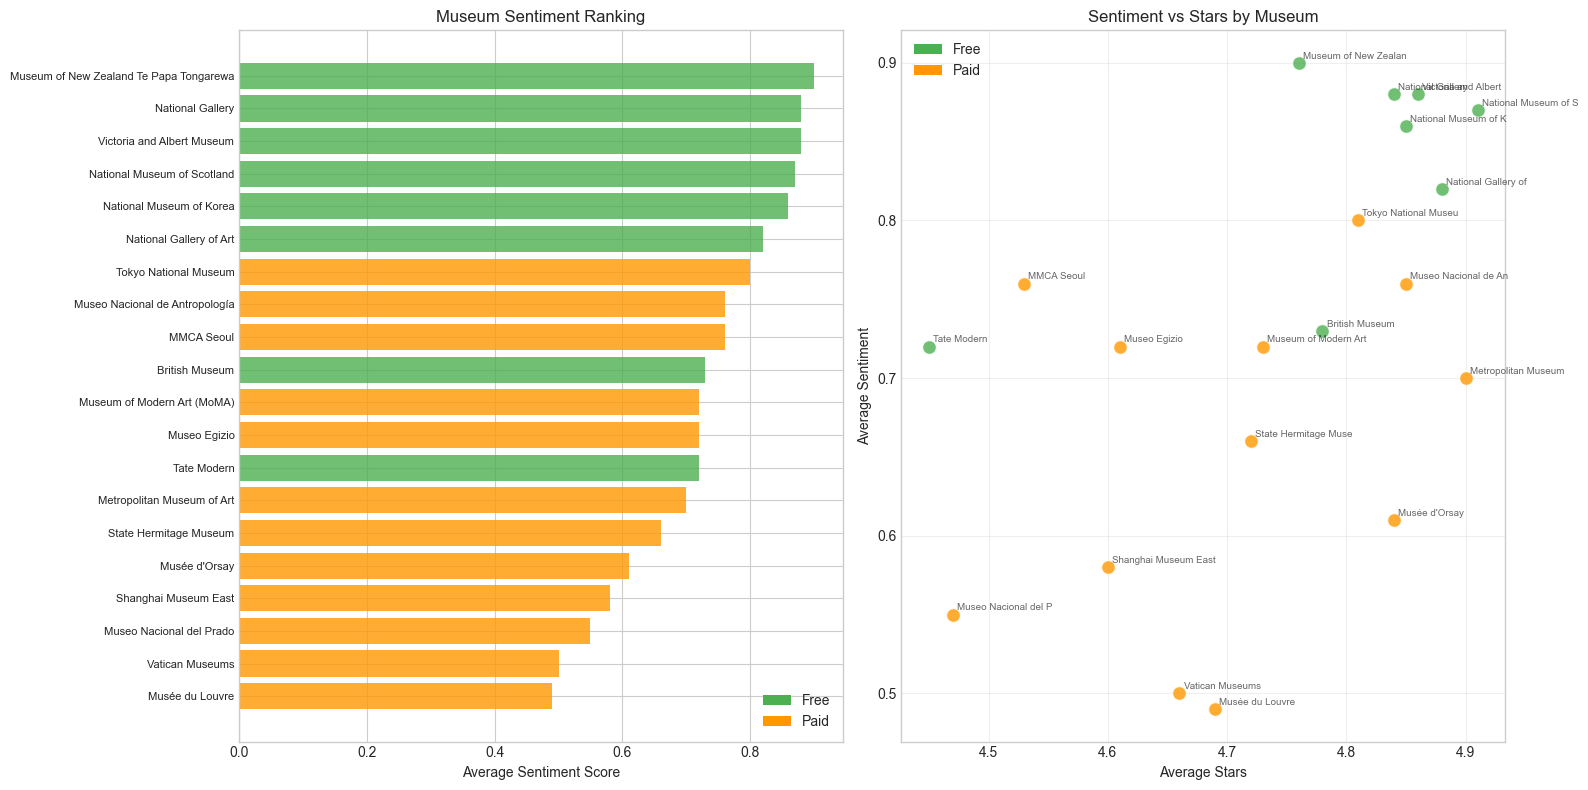

In [39]:
# 감성 점수 시각화: 박물관별 비교
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# 감성 점수 바 차트
sorted_sent = museum_sent.sort_values('avg_sentiment', ascending=True)
colors = ['#4CAF50' if x == 'Y' else '#FF9800' for x in sorted_sent['admission_free_yn']]

ax1.barh(range(len(sorted_sent)), sorted_sent['avg_sentiment'], color=colors, alpha=0.8)
ax1.set_yticks(range(len(sorted_sent)))
ax1.set_yticklabels(sorted_sent['museum'], fontsize=8)
ax1.set_xlabel('Average Sentiment Score')
ax1.set_title('Museum Sentiment Ranking')
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# 범례
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4CAF50', label='Free'),
                   Patch(facecolor='#FF9800', label='Paid')]
ax1.legend(handles=legend_elements, loc='lower right')

# 감성 vs 별점 산점도
for _, r in museum_sent.iterrows():
    color = '#4CAF50' if r['admission_free_yn'] == 'Y' else '#FF9800'
    ax2.scatter(r['avg_stars'], r['avg_sentiment'], c=color, s=100, alpha=0.8, edgecolors='white')
    ax2.annotate(r['museum'][:20], (r['avg_stars'], r['avg_sentiment']),
                fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')

ax2.set_xlabel('Average Stars')
ax2.set_ylabel('Average Sentiment')
ax2.set_title('Sentiment vs Stars by Museum')
ax2.legend(handles=legend_elements)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}figures/sentiment_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 토픽모델링 (LDA)

방문객이 리뷰에서 언급하는 주요 토픽을 추출한다.
- 영어 리뷰만 필터링 (다국어 혼재 방지)
- TF-IDF + LDA (5개 토픽)

In [40]:
# 영어 리뷰 필터링
def is_english(text):
    words = text.split()
    if len(words) < 3:
        return False
    ascii_words = sum(1 for w in words if re.match(r'^[a-zA-Z]+$', w))
    return (ascii_words / len(words)) > 0.5

df['is_english'] = df['text'].apply(is_english)
df_en = df[df['is_english']].copy()
print(f'영어 리뷰: {len(df_en)} / {len(df)} ({len(df_en)/len(df)*100:.1f}%)')

영어 리뷰: 3801 / 3805 (99.9%)


In [41]:
# 스톱워드 (일반 영어 + 박물관 관련 일반 단어)
custom_stop = [
    # 일반 영어 불용어
    'the','and','to','of','a','in','is','it','was','for','on','with','that','this',
    'are','but','not','you','all','can','had','have','her','his','one','our','out',
    'they','were','been','from','has','its','than','more','also','very','much','some',
    'them','there','here','just','like','only','even','well','back','about','will',
    'time','see','make','don','didn','way','lot','many','think','know','take','come',
    'look','want','day','first','going','still','thing','things','quite','really',
    'would','could','should','every','what','when','where','which','who','how','why',
    'do','does','did','being','if','or','an','be','so','at','as','we','my','me',
    'no','up','by','am','too','your','their','into','over','after','before','between',
    'through','during','because','while','other','each','any','most','own','same',
    'another','de','le','la','un','en','el','es','il','di','da',
    # 박물관 관련 일반 단어 (토픽 구분에 도움 안 됨)
    'museum','museums','visit','visited','visiting','place','places','go','went',
    'get','got','people','around','need','said','say','told','ask','asked',
    'little','bit','big','new','old','different','whole','large','small','long','short',
    'two','three','four','one','years','year','hours','hour','minutes','next','last',
    'ever','away','us','ve','ll','re','ft','didn','wasn','isn','aren','couldn','won',
]

# TF-IDF 벡터화
tfidf = TfidfVectorizer(
    max_features=1500,
    stop_words=custom_stop,
    min_df=8,
    max_df=0.6,
    ngram_range=(1, 2),
    token_pattern=r'\b[a-zA-Z]{3,}\b'  # 영어 3글자 이상만
)
X_tfidf = tfidf.fit_transform(df_en['text'])
print(f'TF-IDF matrix: {X_tfidf.shape}')

TF-IDF matrix: (3801, 1500)


In [42]:
# LDA 토픽 모델
N_TOPICS = 5  # 토픽 수 (조정 가능)

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=30,
    learning_method='online',
    doc_topic_prior=0.1,   # alpha: 문서당 토픽 분포 (낮을수록 집중)
    topic_word_prior=0.01  # beta: 토픽당 단어 분포 (낮을수록 집중)
)
lda.fit(X_tfidf)

# 토픽별 상위 키워드
feature_names = tfidf.get_feature_names_out()
print(f'=== {N_TOPICS}개 토픽 ===')
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-16:-1]]
    print(f'\n  Topic {topic_idx}: {", ".join(top_words)}')

=== 5개 토픽 ===

  Topic 0: mona, lisa, mona lisa, madrid, goya, prado, moving, leonardo, louvre, leonardo vinci, russia, sculptures paintings, venus, rubens, staff helpful

  Topic 1: tickets, advance, line, buy, online, ticket, tickets advance, tour, buy tickets, book, guide, queue, tickets online, chapel, wait

  Topic 2: art, free, history, great, amazing, collection, experience, must, beautiful, exhibits, worth, world, building, good, best

  Topic 3: van, gogh, van gogh, monet, tour, night, starry, starry night, train, tour guide, natural history, train station, guide, ended, paintings

  Topic 4: brilliant, liked, quick, ground, shoes, marie, animals, marie antoinette, antoinette, wear, free entrance, ground floor, comfortable shoes, amazing, comfortable


In [43]:
# 리뷰별 주요 토픽 할당
topic_dist = lda.transform(X_tfidf)
df_en['dominant_topic'] = topic_dist.argmax(axis=1)

# 전체 df에 토픽 병합
df = df.merge(df_en[['id', 'dominant_topic']], on='id', how='left')

# 박물관별 토픽 분포
topic_by_museum = (
    df_en.groupby('museum_id')['dominant_topic']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .round(2)
)
print('=== 박물관별 토픽 분포 ===')
print(topic_by_museum.to_string())

=== 박물관별 토픽 분포 ===
dominant_topic     0     1     2     3     4
museum_id                                   
1001            0.00  0.10  0.90  0.00  0.00
1002            0.00  0.26  0.73  0.00  0.00
1003            0.00  0.04  0.96  0.00  0.00
1004            0.00  0.04  0.94  0.00  0.00
1005            0.00  0.00  0.99  0.00  0.01
1006            0.00  0.02  0.96  0.02  0.00
1007            0.01  0.00  0.99  0.00  0.00
1008            0.00  0.00  0.98  0.00  0.01
1009            0.00  0.06  0.93  0.01  0.00
1010            0.00  0.02  0.96  0.00  0.01
1012            0.00  0.05  0.94  0.00  0.01
1013            0.00  0.00  0.97  0.00  0.02
1014            0.01  0.05  0.94  0.00  0.00
1016            0.00  0.02  0.98  0.00  0.00
1017            0.00  0.00  0.98  0.00  0.02
1018            0.00  0.02  0.96  0.01  0.02
1019            0.00  0.00  0.98  0.00  0.02
1020            0.00  0.03  0.96  0.01  0.01
1023            0.00  0.00  0.98  0.01  0.00
1024            0.00  0.00  0.98  0.

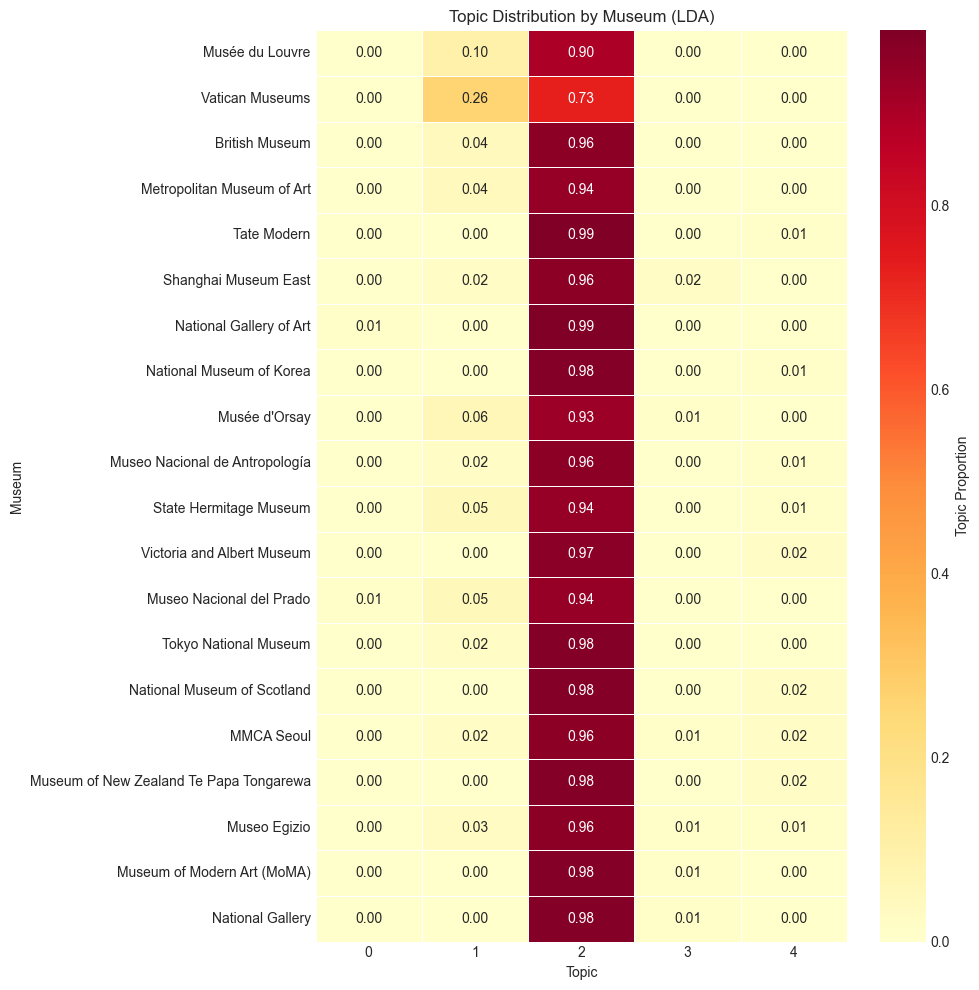

In [44]:
# 토픽 분포 히트맵
topic_vis = topic_by_museum.copy()
topic_vis.index = topic_vis.index.map(
    dict(zip(info['id'], info['museum']))
)

plt.figure(figsize=(10, 10))
sns.heatmap(topic_vis, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Topic Proportion'})
plt.xlabel('Topic')
plt.ylabel('Museum')
plt.title('Topic Distribution by Museum (LDA)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}figures/topic_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 유료 vs 무료 박물관 비교

In [45]:
# 유료/무료 그룹 비교
museum_sent_full = museum_sent.copy()

free_museums = museum_sent_full[museum_sent_full['admission_free_yn'] == 'Y']
paid_museums = museum_sent_full[museum_sent_full['admission_free_yn'] == 'N']

print('=== 유료 vs 무료 박물관 감성 비교 ===')
print(f'\n무료 박물관 ({len(free_museums)}개):')
print(f'  평균 감성: {free_museums["avg_sentiment"].mean():.3f}')
print(f'  평균 별점: {free_museums["avg_stars"].mean():.2f}')
print(f'  긍정 비율: {free_museums["positive_pct"].mean():.1f}%')
print(f'  부정 비율: {free_museums["negative_pct"].mean():.1f}%')

print(f'\n유료 박물관 ({len(paid_museums)}개):')
print(f'  평균 감성: {paid_museums["avg_sentiment"].mean():.3f}')
print(f'  평균 별점: {paid_museums["avg_stars"].mean():.2f}')
print(f'  긍정 비율: {paid_museums["positive_pct"].mean():.1f}%')
print(f'  부정 비율: {paid_museums["negative_pct"].mean():.1f}%')

diff = free_museums['avg_sentiment'].mean() - paid_museums['avg_sentiment'].mean()
print(f'\n감성 차이 (무료-유료): {diff:+.3f}')

=== 유료 vs 무료 박물관 감성 비교 ===

무료 박물관 (8개):
  평균 감성: 0.833
  평균 별점: 4.79
  긍정 비율: 91.4%
  부정 비율: 2.5%

유료 박물관 (12개):
  평균 감성: 0.654
  평균 별점: 4.70
  긍정 비율: 79.4%
  부정 비율: 7.3%

감성 차이 (무료-유료): +0.178


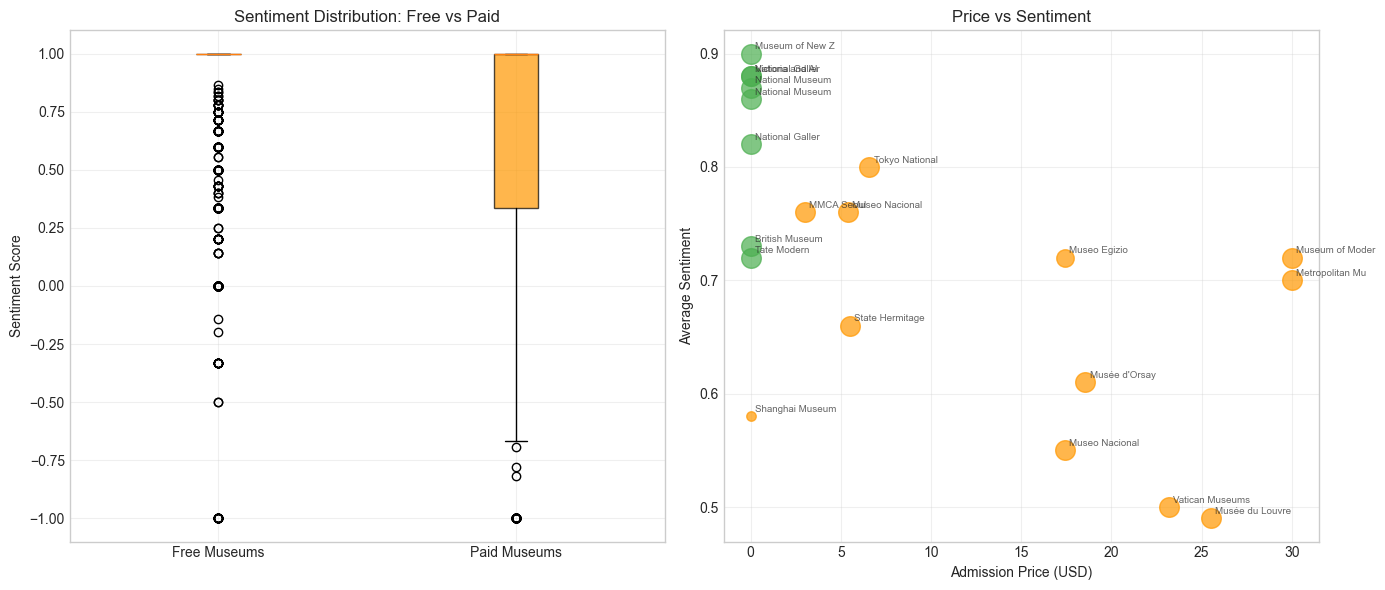

In [46]:
# 유료 vs 무료: 감성 분포 비교 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 박스플롯
free_sentiments = df[df['museum_id'].isin(free_museums['museum_id'])]['sentiment']
paid_sentiments = df[df['museum_id'].isin(paid_museums['museum_id'])]['sentiment']

# ANCHOR 이전
# ax1.boxplot([free_sentiments.dropna(), paid_sentiments.dropna()],
#             labels=['Free Museums', 'Paid Museums'],
#             patch_artist=True,
#             boxprops=[dict(facecolor='#4CAF50', alpha=0.7),
#                       dict(facecolor='#FF9800', alpha=0.7)])
# ANCHOR 수정한 코드 /*
# 수정된 부분 1: 결과를 bp 변수에 받고, 안에서 boxprops 속성을 제거합니다.
bp = ax1.boxplot([free_sentiments.dropna(), paid_sentiments.dropna()],
                 labels=['Free Museums', 'Paid Museums'],
                 patch_artist=True)
# 수정된 부분 2: 생성된 각 박스에 대해 반복문으로 개별적인 색상과 투명도를 적용합니다.
colors = ['#4CAF50', '#FF9800']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
#  */

ax1.set_ylabel('Sentiment Score')
ax1.set_title('Sentiment Distribution: Free vs Paid')
ax1.grid(True, alpha=0.3)

# 입장료 vs 감성 산점도
for _, r in museum_sent_full.iterrows():
    ax2.scatter(r['adult_price_local_usd'], r['avg_sentiment'],
               s=r['review_count'], alpha=0.7,
               c='#4CAF50' if r['admission_free_yn'] == 'Y' else '#FF9800')
    ax2.annotate(r['museum'][:15], (r['adult_price_local_usd'], r['avg_sentiment']),
                fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')

ax2.set_xlabel('Admission Price (USD)')
ax2.set_ylabel('Average Sentiment')
ax2.set_title('Price vs Sentiment')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}figures/free_vs_paid_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 인사이트 & 결과 저장

In [47]:
# 국립중앙박물관 vs 유사 박물관 비교
nmk_sent = museum_sent_full[museum_sent_full['museum_id'] == 1008].iloc[0]

print('=== 국립중앙박물관 감성분석 결과 ===')
print(f'  평균 감성: {nmk_sent["avg_sentiment"]:.3f}')
print(f'  평균 별점: {nmk_sent["avg_stars"]:.2f}')
print(f'  긍정 비율: {nmk_sent["positive_pct"]:.1f}%')
print(f'  부정 비율: {nmk_sent["negative_pct"]:.1f}%')

# 전체 순위
rank = museum_sent_full.sort_values('avg_sentiment', ascending=False).reset_index(drop=True)
nmk_rank = rank[rank['museum_id'] == 1008].index[0] + 1
print(f'  감성 순위: {nmk_rank}/{len(rank)}')

print(f'\n=== 유료 전환 시 시사점 ===')
print(f'  - 국립중앙박물관은 이미 높은 감성 점수를 보유')
print(f'  - 유료 전환 시 "가격 대비 가치" 관련 부정 리뷰 증가 가능')
print(f'  - 유료 박물관 중 부정 비율이 높은 곳: 루브르({museum_sent_full[museum_sent_full["museum_id"]==1001]["negative_pct"].values[0]:.1f}%), 바티칸({museum_sent_full[museum_sent_full["museum_id"]==1002]["negative_pct"].values[0]:.1f}%)')
print(f'  - 이들은 높은 가격($25+)과 과밀(crowded)이 주요 불만 요인')

=== 국립중앙박물관 감성분석 결과 ===
  평균 감성: 0.860
  평균 별점: 4.85
  긍정 비율: 93.5%
  부정 비율: 0.5%
  감성 순위: 5/20

=== 유료 전환 시 시사점 ===
  - 국립중앙박물관은 이미 높은 감성 점수를 보유
  - 유료 전환 시 "가격 대비 가치" 관련 부정 리뷰 증가 가능
  - 유료 박물관 중 부정 비율이 높은 곳: 루브르(12.5%), 바티칸(11.5%)
  - 이들은 높은 가격($25+)과 과밀(crowded)이 주요 불만 요인


In [48]:
# 결과 저장
df.to_csv(f'{OUTPUT_DIR}sentiment_result.csv', index=False)
museum_sent_full.to_csv(f'{OUTPUT_DIR}museum_sentiment_summary.csv', index=False)
topic_by_museum.to_csv(f'{OUTPUT_DIR}museum_topic_distribution.csv')

print('✅ 저장 완료:')
print(f'  - sentiment_result.csv (리뷰별 감성 점수)')
print(f'  - museum_sentiment_summary.csv (박물관별 요약)')
print(f'  - museum_topic_distribution.csv (박물관별 토픽 분포)')

✅ 저장 완료:
  - sentiment_result.csv (리뷰별 감성 점수)
  - museum_sentiment_summary.csv (박물관별 요약)
  - museum_topic_distribution.csv (박물관별 토픽 분포)
